In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
# increase plt fontsize
plt.rcParams.update({'font.size': 20})
import matplotlib as mpl

In [2]:
# colormap for plots
colormap = mpl.colormaps['viridis']

color_m_base = colormap(0.0)
color_m_obs = colormap(0.2)
color_m = colormap(0.2)

color_R = colormap(0.4)
color_del_m_R = colormap(0.4)
#color_m_R = colormap(0.4)

color_C = colormap(0.6)
color_del_m_C = colormap(0.6)
#color_m_C = colormap(0.7)

color_ICU = colormap(0.8)
color_del_m_ICU = colormap(0.8)
#color_m_ICU = colormap(1.0)

# Load data

In [9]:
def get_data(tag_in, BundeslandID_in="Deutschland"):
    path = f"mobilityData_OverviewBL_{tag_in}.csv"
    df = pd.read_csv(path, parse_dates=True, index_col=0, delimiter=";")
    df = df[df["BundeslandID"] == BundeslandID_in]
    df["week"] = df.index.isocalendar().week
    return df

In [63]:
#weekdays_df = get_data("weekdays")
#weekends_df = get_data("weekends")
weekly_df = get_data("weekly")
weekly_NRW = get_data("weekly", "Nordrhein-Westfalen")
weekly_Bayern = get_data("weekly", "Bayern")
weekly_BW = get_data("weekly", "Baden-Württemberg")
#weekly_df

In [5]:
daily_df = pd.read_csv("outOfHomeDuration_Germany_Daily.csv", index_col=0, parse_dates=True)

# Get data by year

In [65]:
def get_mobility_data_by_years(weekly_df_in):
    # get dates
    mobility_dates = weekly_df_in.index.values
    mobility_dates_2020 = mobility_dates[mobility_dates < np.datetime64('2020-12-20')]
    mobility_dates_2020 = mobility_dates_2020[mobility_dates_2020 > np.datetime64('2020-03-15')]
    mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64('2022-12-20')]
    mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020):]

    # get mobility data
    mobility_df_2020 = weekly_df_in.filter(items=mobility_dates_2020, axis=0)
    mobility_df_2022 = weekly_df_in.filter(items=mobility_dates_2022_shortened, axis=0)

    mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()
    mobility_data_2022 = mobility_df_2022["outOfHomeDuration"].to_xarray()

    return mobility_data_2020, mobility_data_2022, mobility_dates_2020, mobility_dates_2022_shortened, mobility_df_2020

In [66]:
mobility_data_2020, mobility_data_2022, mobility_dates_2020, mobility_dates_2022_shortened, mobility_df_2020 = get_mobility_data_by_years(
    weekly_df
    )

mobility_NRW_2020, mobility_NRW_2022, _, _, _ = get_mobility_data_by_years(weekly_NRW)
mobility_Bayern_2020, mobility_Bayern_2022, _, _, _ = get_mobility_data_by_years(weekly_Bayern)
mobility_BW_2020, mobility_BW_2022, _, _, _ = get_mobility_data_by_years(weekly_BW)

# Plot differences

Text(0, 0.5, 'Difference in out of home\nduration $m_{2022} - m_{2020}$ [h]')

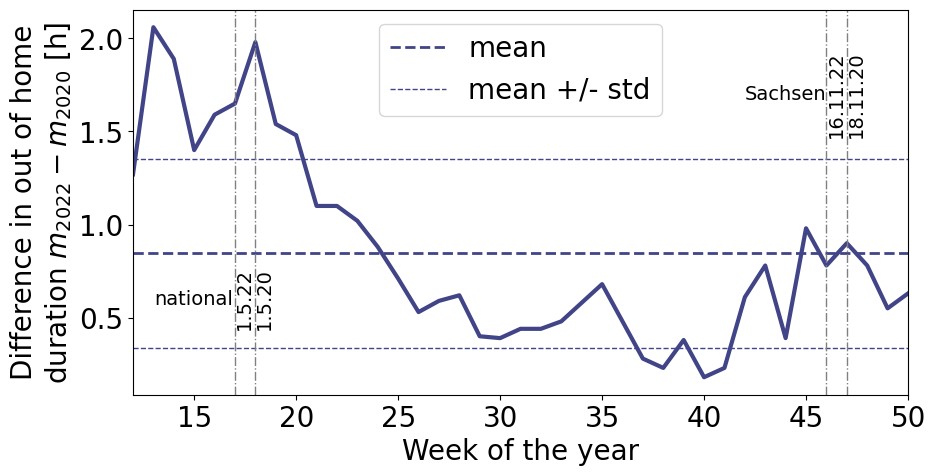

In [111]:
# subtract 2020 mobility from 2022 mobility
differences_m = mobility_data_2022.values - mobility_data_2020.values
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
xs = mobility_df_2020["week"]
ax.plot(xs, differences_m, linewidth=3, color=color_m_obs)
# plot horizontal dashed line for mean difference
ax.axhline(np.mean(differences_m), linestyle="--", color=color_m_obs, linewidth=2, label="mean")
# plot horizontal dashed line for mean difference +/- std
ax.axhline(np.mean(differences_m) + np.std(differences_m), linestyle="--", color=color_m_obs, linewidth=1, label="mean +/- std")
ax.axhline(np.mean(differences_m) - np.std(differences_m), linestyle="--", color=color_m_obs, linewidth=1)

# plot vertical dashed line for problematic dates/weeks
fs = 14
lw = 1
ls = "-."
ax.axvline(xs[5], linestyle=ls, linewidth=lw, color="grey")
ax.axvline(xs[6], linestyle=ls, linewidth=lw, color="grey")
ax.axvline(xs[34], linestyle=ls, linewidth=lw, color="grey")
ax.axvline(xs[35], linestyle=ls, linewidth=lw, color="grey")
## set label beside vertical line
ha = "left"
ax.text(xs[5], 0.6, "1.5.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[6], 0.6, "1.5.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[34], 1.7, "16.11.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[35], 1.7, "18.11.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
## name holidays
ax.text(xs[3], 0.6, "national", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs)
ax.text(xs[32], 1.7, "Sachsen", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs)

ax.legend()
ax.set_xlim(xs[0], xs[-1])
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2022}} - m_{{2020}}$ [h]")

# Create baseline mobility data

using 2022 mobility data as a start

In [254]:
baseline_mobility = mobility_data_2022.copy(deep=True)

## Mapping

In [261]:
mobility_dates_2020

array(['2020-03-22T00:00:00.000000000', '2020-03-29T00:00:00.000000000',
       '2020-04-05T00:00:00.000000000', '2020-04-12T00:00:00.000000000',
       '2020-04-19T00:00:00.000000000', '2020-04-26T00:00:00.000000000',
       '2020-05-03T00:00:00.000000000', '2020-05-10T00:00:00.000000000',
       '2020-05-17T00:00:00.000000000', '2020-05-24T00:00:00.000000000',
       '2020-05-31T00:00:00.000000000', '2020-06-07T00:00:00.000000000',
       '2020-06-14T00:00:00.000000000', '2020-06-21T00:00:00.000000000',
       '2020-06-28T00:00:00.000000000', '2020-07-05T00:00:00.000000000',
       '2020-07-12T00:00:00.000000000', '2020-07-19T00:00:00.000000000',
       '2020-07-26T00:00:00.000000000', '2020-08-02T00:00:00.000000000',
       '2020-08-09T00:00:00.000000000', '2020-08-16T00:00:00.000000000',
       '2020-08-23T00:00:00.000000000', '2020-08-30T00:00:00.000000000',
       '2020-09-06T00:00:00.000000000', '2020-09-13T00:00:00.000000000',
       '2020-09-20T00:00:00.000000000', '2020-09-27

In [263]:
mobility_dates_2022_shortened

array(['2022-03-27T00:00:00.000000000', '2022-04-03T00:00:00.000000000',
       '2022-04-10T00:00:00.000000000', '2022-04-17T00:00:00.000000000',
       '2022-04-24T00:00:00.000000000', '2022-05-01T00:00:00.000000000',
       '2022-05-08T00:00:00.000000000', '2022-05-15T00:00:00.000000000',
       '2022-05-22T00:00:00.000000000', '2022-05-29T00:00:00.000000000',
       '2022-06-05T00:00:00.000000000', '2022-06-12T00:00:00.000000000',
       '2022-06-19T00:00:00.000000000', '2022-06-26T00:00:00.000000000',
       '2022-07-03T00:00:00.000000000', '2022-07-10T00:00:00.000000000',
       '2022-07-17T00:00:00.000000000', '2022-07-24T00:00:00.000000000',
       '2022-07-31T00:00:00.000000000', '2022-08-07T00:00:00.000000000',
       '2022-08-14T00:00:00.000000000', '2022-08-21T00:00:00.000000000',
       '2022-08-28T00:00:00.000000000', '2022-09-04T00:00:00.000000000',
       '2022-09-11T00:00:00.000000000', '2022-09-18T00:00:00.000000000',
       '2022-09-25T00:00:00.000000000', '2022-10-02

## Workers' day

In 2020, the national holiday on 1st of May is on a weekday in the week corresponding to the entry 6 in the 2020 mobility data set. To account for this, we will adapt the baseline mobility in the corresponding week. Currently, every entry in the data set is the average out of home duration of a week placed on the Sunday of the same week. To account for the extra holiday, we will replace the 2022 entry 6  with a modified average: Instead of 

average $= \frac{1}{7} (5 \cdot \text{business day average} + 2 \cdot \text{weekend average})$ 

we calculate 

average $= \frac{1}{7} (4 \cdot \text{business day average} + 3 \cdot \text{weekend average})$.

In [255]:
# get out of home duration data for week ending with given date
def get_out_of_home_durations(date_in):
    out_of_home_durations = []
    for i in range(7):
        d = 6-i
        date = date_in - np.timedelta64(d, 'D')
        out_of_home_durations.append(daily_df.loc[date]["outOfHomeDuration"])
    return out_of_home_durations

In [256]:
sunday_date_1_5_22 = mobility_data_2022[6].date.values
out_of_home_durations = get_out_of_home_durations(sunday_date_1_5_22)

# calculate modified average
weekday_average = np.mean(out_of_home_durations[:5])
weekend_average = np.mean(out_of_home_durations[5:])
modified_average = (weekday_average * 4 + weekend_average * 3) / 7

# round to 2 decimal places
modified_average = round(modified_average, 2)

# update baseline mobility
baseline_mobility[6] = modified_average

## Buß- und Bettag
Even though there is a similar problem for this holiday, it only concerns Sachsen; with 4 million inhabitants it only makes up 5% of the population, so we will neglect it and not correct for it.

**Discarded:** We will treat the holiday Buß- und Bettag in Sachsen (saxony) similarly.
In the 2022 data set, it falls on the Wednesday corresponding to entry 34. This means that there is one business day less in this week than in the corresponding week in 2020. Hence, we will replace the Wednesday data point in 2022 with the average of the other business days in the same week.--

In [121]:
# sunday_date_16_11_20 = mobility_data_2022[34].date.values
# out_of_home_durations = get_out_of_home_durations(sunday_date_16_11_20)

# # calculate modified average
# out_of_home_durations.pop(2)
# weekday_average = np.mean(out_of_home_durations[:4])
# weekend_average = np.mean(out_of_home_durations[4:])
# modified_average = (weekday_average * 5 + weekend_average * 2) / 7

# # round to 2 decimal places
# modified_average = round(modified_average, 2)

# # update baseline mobility
# baseline_mobility[34] = modified_average

**Discarded:** To account for Buß- und Bettag on 18.11.2020 we have to modify entry 35 of the baseline data set analogously to the 1st of May.

In [125]:
# out_of_home_durations = get_out_of_home_durations(mobility_data_2022[35].date.values)

# # calculate modified average
# weekday_average = np.mean(out_of_home_durations[:5])
# weekend_average = np.mean(out_of_home_durations[5:])
# modified_average = (weekday_average * 4 + weekend_average * 3) / 7

# # round to 2 decimal places
# modified_average = round(modified_average, 2)

# # update baseline mobility
# baseline_mobility[35] = modified_average

# Save data

Save baseline and 2020 mobility data set.

In [257]:
baseline_df = baseline_mobility.to_dataframe(name="outOfHomeDuration")
baseline_df.to_csv("baseline_mobility.csv", float_format="%.2f")

In [258]:
df_2020 = mobility_data_2020.to_dataframe(name="outOfHomeDuration")
df_2020.to_csv("2020_mobility.csv", float_format="%.2f")

# Plot differences again

Text(0, 0.5, 'Difference in\nout of home duration [h]')

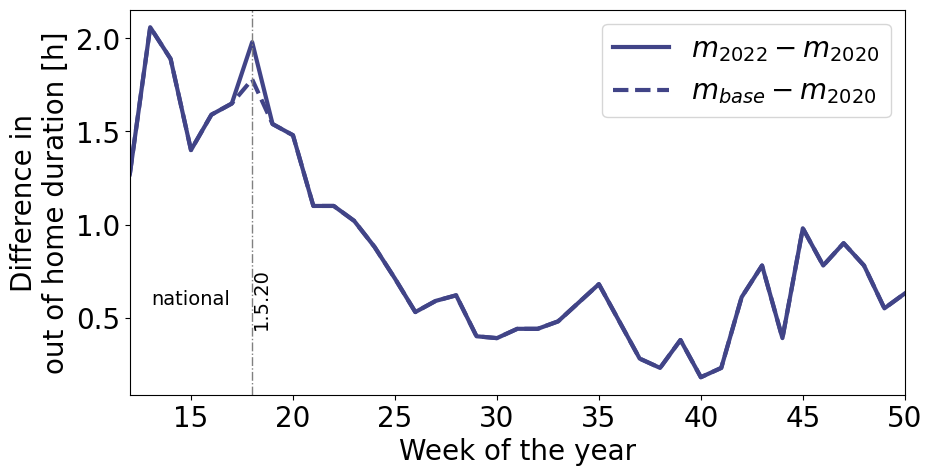

In [260]:
# subtract 2020 mobility from 2022 mobility
differences_base = baseline_mobility.values - mobility_data_2020.values
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
xs = mobility_df_2020["week"]
ax.plot(xs, differences_m, linewidth=3, color=color_m_obs, label="$m_{{2022}} - m_{{2020}}$")
ax.plot(xs, differences_base, linewidth=3, color=color_m_obs, linestyle="--", label="$m_{{base}} - m_{{2020}}$")

# plot vertical dashed line for problematic dates/weeks
fs = 14
lw = 1
ls = "-."
#ax.axvline(xs[5], linestyle=ls, linewidth=lw, color="grey")
ax.axvline(xs[6], linestyle=ls, linewidth=lw, color="grey")
#ax.axvline(xs[34], linestyle=ls, linewidth=lw, color="grey")
#ax.axvline(xs[35], linestyle=ls, linewidth=lw, color="grey")
## set label beside vertical line
ha = "left"
#ax.text(xs[5], 0.6, "1.5.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[6], 0.6, "1.5.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
#ax.text(xs[34], 1.7, "16.11.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
#ax.text(xs[35], 1.7, "18.11.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
## name holidays
ax.text(xs[3], 0.6, "national", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs)
#ax.text(xs[32], 1.7, "Sachsen", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs)

ax.legend()
ax.set_xlim(xs[0], xs[-1])
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in\nout of home duration [h]")

# School holidays

## Load data

In [7]:
def string_to_date(string_in, year_in):
    string = string_in + f".{year_in}"
    return pd.to_datetime(string, format="%d.%m.%Y")

def convert_to_dates(string_in, year_in):
    # check if string is not nan
    if string_in == string_in:
        strings = string_in.split(", ")
        dates = []
        for i in range(len(strings)):
            string = strings[i]
            if "-" in string:
                date_strings = string.split(" - ")
                start_date = string_to_date(date_strings[0], year_in)
                end_date = string_to_date(date_strings[1], year_in)
                dates.append((start_date, end_date))
            else:
                dates.append(string_to_date(string, year_in))
        return dates
    else:
        return np.nan

# apply convert_to_dates to whole dataframe
def convert_df_to_dates(df_in, year_in):
    # new dataframe with same indices and columns
    df_out = pd.DataFrame(index=df_in.index, columns=df_in.columns)
    for column in df_in.columns:
        df_out[column] = df_in[column].apply(convert_to_dates, args=(year_in,))
    return df_out

# check position of date in array (date in array is Sunday of same week)
def get_index_of_date(date_in, datearray_in):
    for i in range(len(datearray_in)):
        if datearray_in[i] == date_in or datearray_in[i] > date_in:
            return i

# convert date_list to indices
def convert_date_list_to_indices(list_in, datearray_in):
    indices = []
    if list_in != list_in:
        return np.nan
    else:
        for element in list_in:
            if type(element) == tuple:
                start_date = element[0]
                end_date = element[1]
                start_index = get_index_of_date(start_date, datearray_in)
                end_index = get_index_of_date(end_date, datearray_in)
                indices.append((start_index, end_index))
            else:
                indices.append(get_index_of_date(element, datearray_in))
        return indices

# apply convert_date_list_to_indices to whole dataframe
def convert_df_to_indices(df_in, datearray_in):
    # new dataframe with same indices and columns
    df_out = pd.DataFrame(index=df_in.index, columns=df_in.columns)
    for column in df_in.columns:
        df_out[column] = df_in[column].apply(convert_date_list_to_indices, args=(datearray_in,))
    return df_out

def convert_df(df_in, year_in, datearray_in):
    df_in = convert_df_to_dates(df_in, year_in)
    df_in = convert_df_to_indices(df_in, datearray_in)
    return df_in

def get_holiday_length(list_in):
    if list_in != list_in:
        return np.nan
    else:
        lengths = []
        for element in list_in:
            if type(element) == tuple:
                start_date = element[0]
                end_date = element[1]
                length = end_date - start_date + 1
                lengths.append(length)
            else:
                lengths.append(1)
        return lengths
    
def get_holiday_lengths(df_in):
    # new dataframe with same indices and columns
    df_out = pd.DataFrame(index=df_in.index, columns=df_in.columns)
    for column in df_in.columns:
        df_out[column] = df_in[column].apply(get_holiday_length)
    return df_out

In [8]:
# get data
school_holidays_2020 = pd.read_csv("../holidays/school_holidays_2020.csv", delimiter=";", index_col=0)
school_holidays_2022 = pd.read_csv("../holidays/school_holidays_2022.csv", delimiter=";", index_col=0)

# format data
school_holidays_dates_2020 = convert_df_to_dates(school_holidays_2020, 2020)
school_holidays_dates_2022 = convert_df_to_dates(school_holidays_2022, 2022)

school_holidays_indices_2020 = convert_df_to_indices(school_holidays_dates_2020, mobility_dates_2020)
school_holidays_indices_2022 = convert_df_to_indices(school_holidays_dates_2022, mobility_dates_2022_shortened)

school_holiday_lengths_2020 = get_holiday_lengths(school_holidays_2020)
school_holiday_lengths_2022 = get_holiday_lengths(school_holidays_2022)

## Plot

### Preparation

In [17]:
school_holidays = school_holidays_2020.columns
school_holiday_titles = ["Easter", "Pfingsten", "Summer", "Autumn"]
states = school_holidays_2020.index

In [18]:
def population_string_to_number(string_in):
    string = string_in.replace("\xa0", "")
    return int(string)

In [19]:
population_bundesland = pd.read_csv("population_bundesland.csv", delimiter=";", index_col=0)
# apply format function to population column
population_bundesland["Einwohner"] = population_bundesland["Einwohner"].apply(population_string_to_number)

colormap_states = mpl.colormaps['cividis']
max_pop = population_bundesland["Einwohner"].max()

### Holiday overview

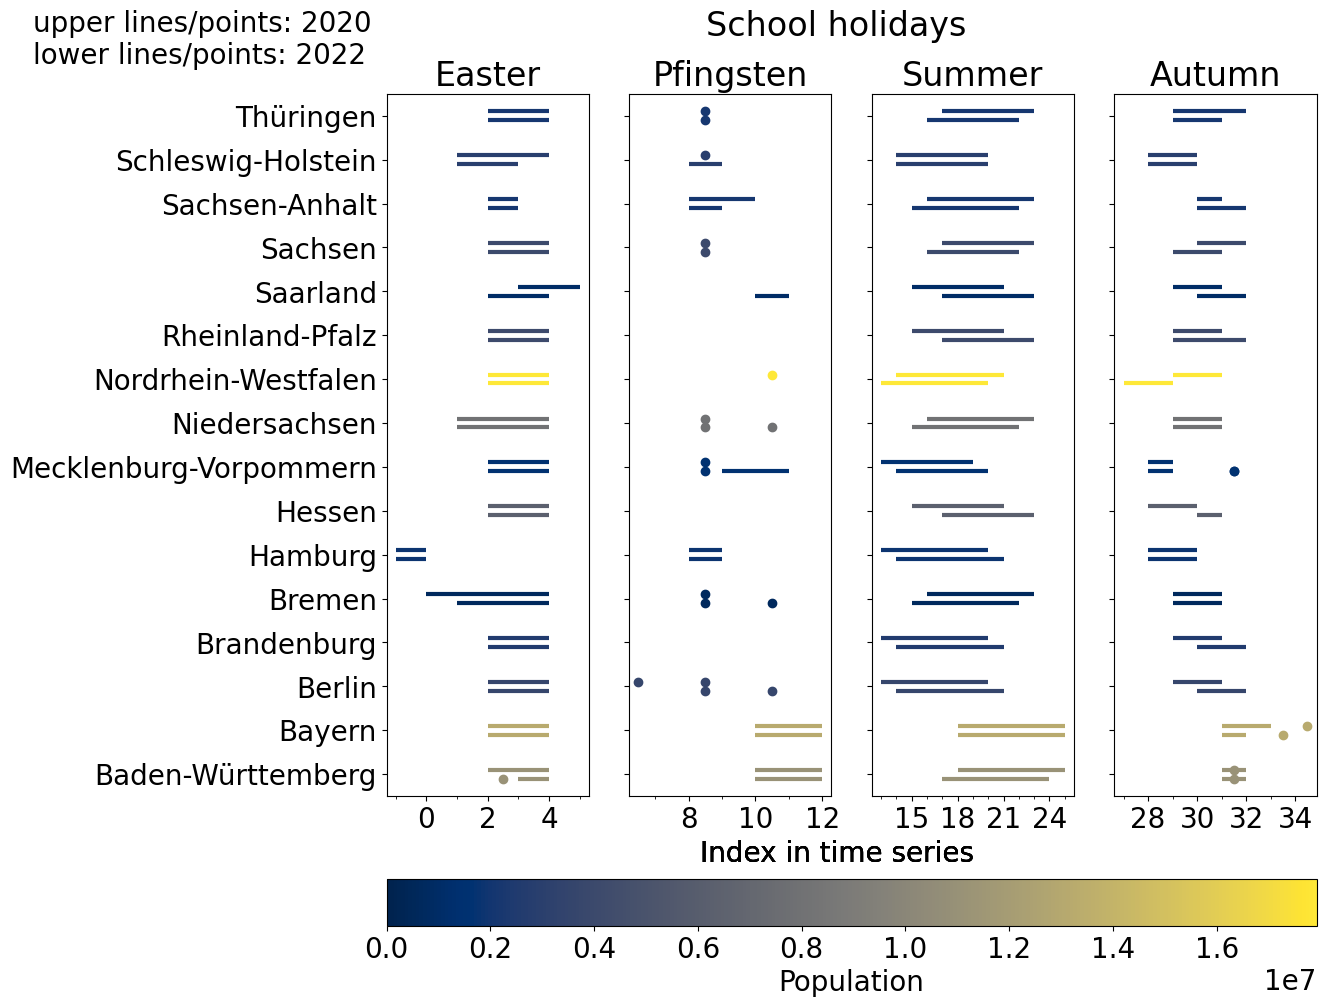

In [20]:
shift = 0.1
lw = 3
mls = [2, 2, 3, 2]

# plot holidays on timeline grouped by index (state) and comparing 2020 and 2022
# make a panel for each of the 4 holidays
fig, axs = plt.subplots(1, 4, figsize=(12, 12), sharey=True)
fig.suptitle("School holidays", y=0.95)
axs = axs.flatten()
for i in range(4):
    ax = axs[i]
    holiday = school_holidays[i]
    ax.set_title(school_holiday_titles[i])
    # plot horizontal lines for each state
    for j in range(len(states)):
        state = states[j]
        color_state = colormap_states(population_bundesland.loc[state]["Einwohner"]/max_pop)

        # 2020
        holiday_data_2020 = school_holidays_indices_2020.loc[state][holiday]
        if holiday_data_2020 == holiday_data_2020:
            for element in holiday_data_2020:
                if type(element) == tuple:
                    start = element[0]
                    end = element[1]
                    ax.hlines(y=j+shift, xmin=start-1, xmax=end, linewidth=lw, color=color_state)
                else:
                    ax.scatter(x=element-0.5, y=j+shift, color=color_state)

        # 2022            
        holiday_data_2022 = school_holidays_indices_2022.loc[state][holiday]
        if holiday_data_2022 == holiday_data_2022:
            for element in holiday_data_2022:
                if type(element) == tuple:
                    start = element[0]
                    end = element[1]
                    ax.hlines(y=j-shift, xmin=start-1, xmax=end, linewidth=lw, color=color_state)
                else:
                    ax.scatter(x=element-0.5, y=j-shift, color=color_state)

    # xlabel
    fig.text(0.5, 0.24, 'Index in time series', ha='center')

    # set number of xticks
    ## set major ticks
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(mls[i]))
    ## set minor ticks without labels
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))

    # set ytick labels
    ax.set_yticks(range(len(states)))
    ax.set_yticklabels(states)
    ax.set_ylim(-0.5, len(states)-0.5)

# colorbar
fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=max_pop), cmap=colormap_states), 
             ax=axs, 
             orientation="horizontal", 
             label="Population",
             location="bottom",
             pad=0.09,
             )

fig.text(-0.17, 0.95, 'upper lines/points: 2020\nlower lines/points: 2022', ha='left', va='top')

fig.savefig("../../figures/school_holidays.png", bbox_inches="tight")
fig.savefig("../../figures/school_holidays.pdf", bbox_inches="tight")

In [127]:
school_holidays_dates_2020.loc['Bayern']['Herbstferien']

[(Timestamp('2020-10-31 00:00:00'), Timestamp('2020-11-06 00:00:00')),
 Timestamp('2020-11-18 00:00:00')]

### Holiday overview with lengths

In [275]:
def calculate_date_differences(df_in, index_df_in, dates_in):
    df_out = pd.DataFrame(index=df_in.index, columns=df_in.columns)
    for holiday in df_in.columns:
        for i in range(len(df_in[holiday])):
            holiday_data = df_in[holiday][i]
            if holiday_data == holiday_data:
                ls = []
                for j in range(len(holiday_data)):
                    element = holiday_data[j]
                    if type(element) == tuple:
                        start_date = element[0]
                        start_index = index_df_in[holiday][i][j][0]
                        sunday_date = dates_in[start_index]
                        delta_start = sunday_date - start_date

                        end_date = element[1]
                        end_index = index_df_in[holiday][i][j][1]
                        sunday_date = dates_in[end_index]
                        delta_end = sunday_date - end_date

                        ls.append(((delta_start, start_index), (delta_end, end_index)))
                    else:
                        index = index_df_in[holiday][i][j]
                        sunday_date = dates_in[index]
                        delta = sunday_date - element
                        ls.append((delta, index))
                df_out[holiday][i] = ls
            else:
                df_out[holiday][i] = np.nan
    return df_out

date_differences_2020 = calculate_date_differences(school_holidays_dates_2020, school_holidays_indices_2020, mobility_dates_2020)
date_differences_2022 = calculate_date_differences(school_holidays_dates_2022, 
                                                   school_holidays_indices_2022, 
                                                   mobility_dates_2022_shortened
                                                   )

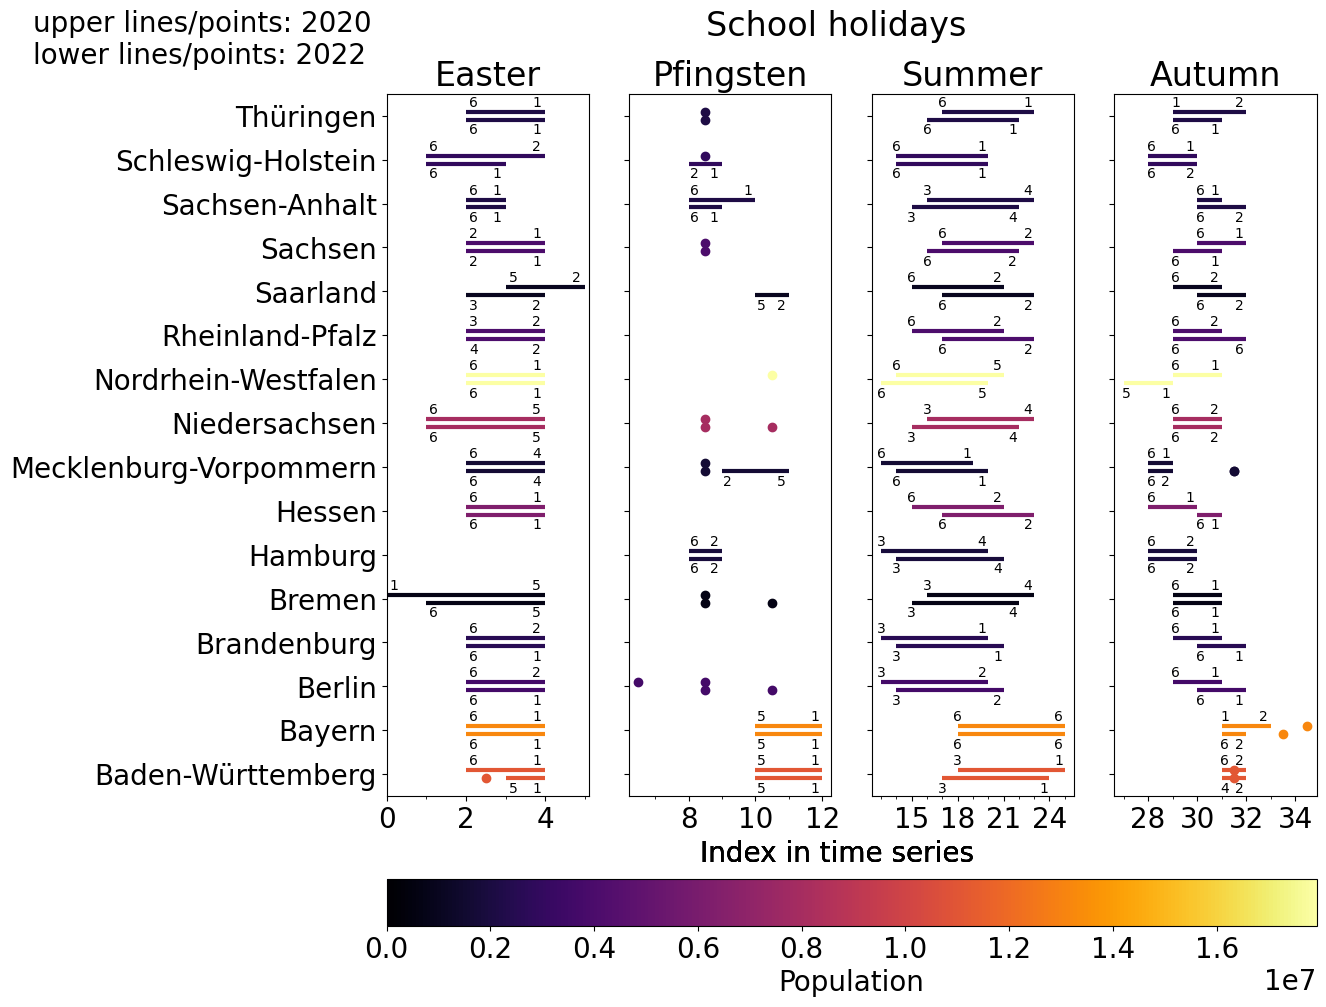

In [297]:
shift = 0.09
lw = 3
mls = [2, 2, 3, 2]

# plot holidays on timeline grouped by index (state) and comparing 2020 and 2022
# make a panel for each of the 4 holidays
fig, axs = plt.subplots(1, 4, figsize=(12, 12), sharey=True)
fig.suptitle("School holidays", y=0.95)
axs = axs.flatten()
for i in range(4):
    ax = axs[i]
    holiday = school_holidays[i]
    ax.set_title(school_holiday_titles[i])
    if i == 0:
        ax.set_xlim(0, 5.1)
    # plot horizontal lines for each state
    for j in range(len(states)):
        state = states[j]
        if i==0 and state=="Hamburg":
            continue
        color_state = colormap_states(population_bundesland.loc[state]["Einwohner"]/max_pop)

        # 2020
        holiday_data_2020 = school_holidays_indices_2020.loc[state][holiday]
        if holiday_data_2020 == holiday_data_2020:
            for element in holiday_data_2020:
                if type(element) == tuple:
                    start = element[0]
                    end = element[1]
                    ax.hlines(y=j+shift, xmin=start-1, xmax=end, linewidth=lw, color=color_state)
                    
                    start_tuple, end_tuple = date_differences_2020[holiday][j][holiday_data_2020.index(element)]
                    ax.text(x=start-0.7, y=j+shift+0.05, s=f"{start_tuple[0].days}", ha='right', va='bottom', fontsize=10)
                    ax.text(x=end-0.1, y=j+shift+0.05, s=f"{end_tuple[0].days}", ha='right', va='bottom', fontsize=10)
                else:
                    ax.scatter(x=element-0.5, y=j+shift, color=color_state)

        # 2022            
        holiday_data_2022 = school_holidays_indices_2022.loc[state][holiday]
        if holiday_data_2022 == holiday_data_2022:
            for element in holiday_data_2022:
                if type(element) == tuple:
                    start = element[0]
                    end = element[1]
                    ax.hlines(y=j-shift, xmin=start-1, xmax=end, linewidth=lw, color=color_state)

                    start_tuple, end_tuple = date_differences_2022[holiday][j][holiday_data_2022.index(element)]
                    ax.text(x=start-0.7, y=j-shift-0.4, s=f"{start_tuple[0].days}", ha='right', va='bottom', fontsize=10)
                    ax.text(x=end-0.1, y=j-shift-0.4, s=f"{end_tuple[0].days}", ha='right', va='bottom', fontsize=10)
                else:
                    ax.scatter(x=element-0.5, y=j-shift, color=color_state)

    # xlabel
    fig.text(0.5, 0.24, 'Index in time series', ha='center')

    # set number of xticks
    ## set major ticks
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(mls[i]))
    ## set minor ticks without labels
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))

    # set ytick labels
    ax.set_yticks(range(len(states)))
    ax.set_yticklabels(states)
    ax.set_ylim(-0.5, len(states)-0.5)

    # grid vertical
    #ax.grid(axis="x", color="grey", linestyle="-", linewidth=1)

# colorbar
fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=max_pop), cmap=colormap_states), 
             ax=axs, 
             orientation="horizontal", 
             label="Population",
             location="bottom",
             pad=0.09,
             )

# custom legend: upper line: 2020, lower line: 2022
# custom_lines = [mpl.lines.Line2D([0], [0], color='k', lw=lw),
#                 mpl.lines.Line2D([0], [0], color='k', lw=lw)]
# axs[0].legend(custom_lines, ['2020', '2022'], bbox_to_anchor=(-0.1, -0.1))
fig.text(-0.17, 0.95, 'upper lines/points: 2020\nlower lines/points: 2022', ha='left', va='top')

fig.savefig("../../figures/school_holidays_delta.png", bbox_inches="tight")
fig.savefig("../../figures/school_holidays_delta.pdf", bbox_inches="tight")

In [68]:
# print differences
def print_differences_between_years(df_2020, df_2022):
    for column in df_2020.columns:
        for i in range(len(df_2020[column])):
            indices1 = df_2020[column][i]
            indices2 = df_2022[column][i]
            if indices1 != indices2 and not (indices1 != indices1 and indices2 != indices2):
                print(column, df_2020.index[i], "2020:", df_2020[column][i], ", 2022:", df_2022[column][i])

In [69]:
print_differences_between_years(school_holidays_indices_2020, school_holidays_indices_2022)

Osterferien Baden-Württemberg 2020: [(3, 4)] 2022: [3, (4, 4)]
Osterferien Bremen 2020: [(1, 4)] 2022: [(2, 4)]
Osterferien Saarland 2020: [(4, 5)] 2022: [(3, 4)]
Osterferien Schleswig-Holstein 2020: [(2, 4)] 2022: [(2, 3)]
Pfingstferien Berlin 2020: [7, 9] 2022: [9, 11]
Pfingstferien Bremen 2020: [9] 2022: [9, 11]
Pfingstferien Mecklenburg-Vorpommern 2020: [9] 2022: [9, (10, 11)]
Pfingstferien Niedersachsen 2020: [9] 2022: [9, 11]
Pfingstferien Nordrhein-Westfalen 2020: [11] 2022: nan
Pfingstferien Saarland 2020: nan 2022: [(11, 11)]
Pfingstferien Sachsen-Anhalt 2020: [(9, 10)] 2022: [(9, 9)]
Pfingstferien Schleswig-Holstein 2020: [9] 2022: [(9, 9)]
Sommerferien Baden-Württemberg 2020: [(19, 25)] 2022: [(18, 24)]
Sommerferien Berlin 2020: [(14, 20)] 2022: [(15, 21)]
Sommerferien Brandenburg 2020: [(14, 20)] 2022: [(15, 21)]
Sommerferien Bremen 2020: [(17, 23)] 2022: [(16, 22)]
Sommerferien Hamburg 2020: [(14, 20)] 2022: [(15, 21)]
Sommerferien Hessen 2020: [(16, 21)] 2022: [(18, 23)]


In [70]:
print_differences_between_years(school_holiday_lengths_2020, school_holiday_lengths_2022)

Osterferien Baden-Württemberg 2020: [2] 2022: [1, 1]
Osterferien Bremen 2020: [4] 2022: [3]
Osterferien Schleswig-Holstein 2020: [3] 2022: [2]
Pfingstferien Bremen 2020: [1] 2022: [1, 1]
Pfingstferien Mecklenburg-Vorpommern 2020: [1] 2022: [1, 2]
Pfingstferien Niedersachsen 2020: [1] 2022: [1, 1]
Pfingstferien Nordrhein-Westfalen 2020: [1] 2022: nan
Pfingstferien Saarland 2020: nan 2022: [1]
Pfingstferien Sachsen-Anhalt 2020: [2] 2022: [1]
Herbstferien Bayern 2020: [2, 1] 2022: [1, 1]
Herbstferien Hessen 2020: [2] 2022: [1]
Herbstferien Mecklenburg-Vorpommern 2020: [1] 2022: [1, 1, 1]
Herbstferien Rheinland-Pfalz 2020: [2] 2022: [3]
Herbstferien Sachsen-Anhalt 2020: [1] 2022: [2]
Herbstferien Thüringen 2020: [3] 2022: [2]


### Mobility in holiday states

Text(0, 0.5, 'Difference in out of home\nduration $m_{2022} - m_{2020}$ [h]')

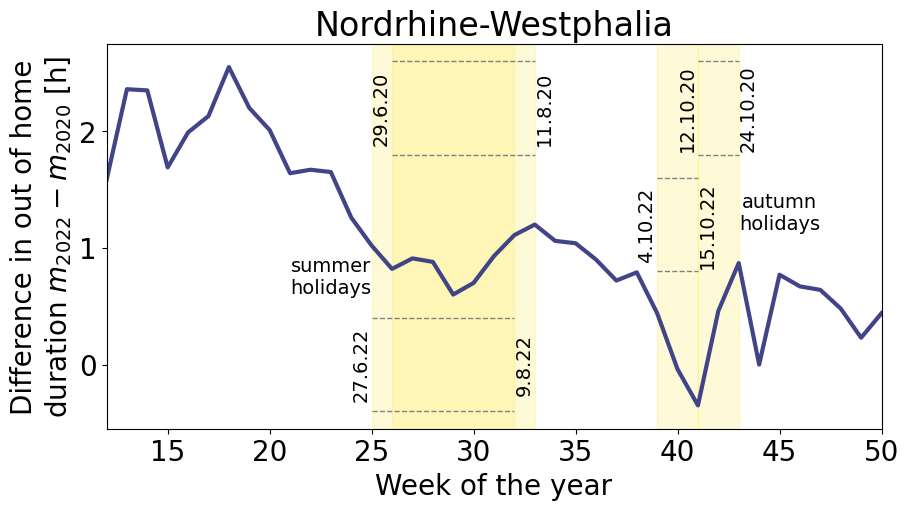

In [61]:
# subtract 2020 mobility from 2022 mobility
differences_m_NRW = mobility_NRW_2022.values - mobility_NRW_2020.values
# color
color_NRW = colormap_states(population_bundesland.loc["Nordrhein-Westfalen"]["Einwohner"]/max_pop)
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
xs = mobility_df_2020["week"]
ax.plot(xs, differences_m_NRW, linewidth=3, color=color_m_obs)

# plot vertical dashed line for problematic dates/weeks
fs = 14
lw = 1
ls = "-."

## set label beside vertical line

ha = "left"
first_height = 0
end_height = 2.2
autumn_2022_height = 1.2

### summer
ax.text(xs[12], first_height, "27.6.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[13], end_height, "29.6.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[20], first_height, "9.8.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[21], end_height, "11.8.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
### autumn
ax.text(xs[26], autumn_2022_height, "4.10.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[28], end_height, "12.10.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[29], autumn_2022_height, "15.10.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[31], end_height, "24.10.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)

## name holidays
ax.text(
    xs[11], 0.75, "summer\nholidays", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs
    )
ax.text(
    xs[33], 1.3, "autumn\nholidays", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs
    )

# plot horizontal dashed line to show lenght of school holidays
## summer
ax.hlines(first_height-0.4, xs[13], xs[20], linestyle="--", linewidth=lw, color="grey")
ax.hlines(first_height+0.4, xs[13], xs[20], linestyle="--", linewidth=lw, color="grey")
ax.hlines(end_height-0.4, xs[14], xs[21], linestyle="--", linewidth=lw, color="grey")
ax.hlines(end_height+0.4, xs[14], xs[21], linestyle="--", linewidth=lw, color="grey")
## autumn
ax.hlines(autumn_2022_height-0.4, xs[27], xs[29], linestyle="--", linewidth=lw, color="grey")
ax.hlines(autumn_2022_height+0.4, xs[27], xs[29], linestyle="--", linewidth=lw, color="grey")
ax.hlines(end_height-0.4, xs[29], xs[31], linestyle="--", linewidth=lw, color="grey")
ax.hlines(end_height+0.4, xs[29], xs[31], linestyle="--", linewidth=lw, color="grey")

# fill between vertical lines for each holiday
### summer
ax.axvspan(xs[13], xs[20], alpha=0.2, color=color_NRW)
ax.axvspan(xs[14], xs[21], alpha=0.2, color=color_NRW)
### autumn
ax.axvspan(xs[27], xs[29], alpha=0.2, color=color_NRW)
ax.axvspan(xs[29], xs[31], alpha=0.2, color=color_NRW)

#ax.legend()
ax.set_title("Nordrhine-Westphalia")
ax.set_xlim(xs[0], xs[-1])
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2022}} - m_{{2020}}$ [h]")

Text(0, 0.5, 'Difference in out of home\nduration $m_{2022} - m_{2020}$ [h]')

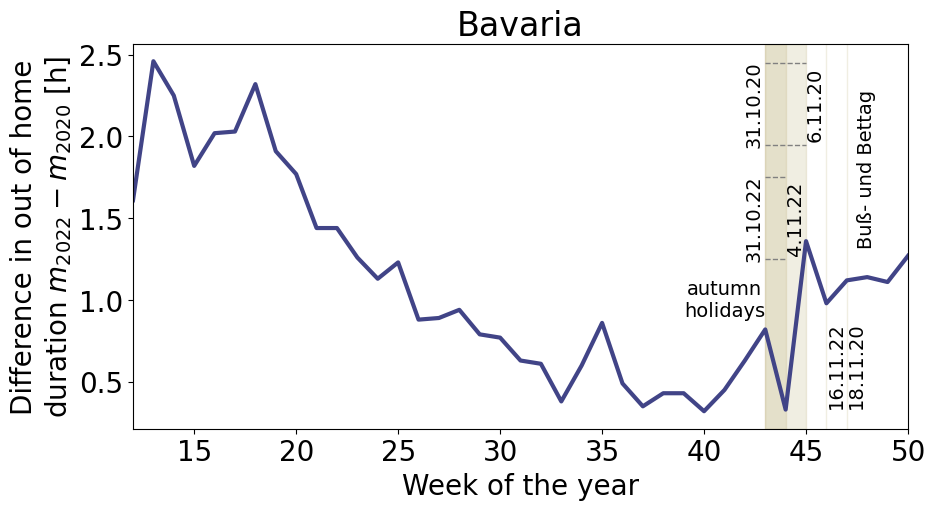

In [128]:
# subtract 2020 mobility from 2022 mobility
differences_m_Bayern = mobility_Bayern_2022.values - mobility_Bayern_2020.values
# color
color_Bayern = colormap_states(population_bundesland.loc["Bayern"]["Einwohner"]/max_pop)
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
xs = mobility_df_2020["week"]
ax.plot(xs, differences_m_Bayern, linewidth=3, color=color_m_obs)

fs = 14
lw = 1

# set label beside vertical line
ha = "left"
autumn_2020_height = 2.2
autumn_2022_height = 1.5
## autumn 2020
ax.text(xs[30], autumn_2020_height, "31.10.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[33], autumn_2020_height, "6.11.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
## autumn 2022
ax.text(xs[30], autumn_2022_height, "31.10.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[32], autumn_2022_height, "4.11.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
## Buß- und Bettag
ax.text(xs[35], 0.6, "18.11.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[34], 0.6, "16.11.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[35]+0.5, 1.8, "Buß- und Bettag", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)

## name holidays
ax.text(
    xs[29], 1, "autumn\nholidays", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs
    )

# plot horizontal dashed line to show length of school holidays
delta = 0.25
## autumn 2020
ax.hlines(autumn_2020_height-delta, xs[31], xs[33], linestyle="--", linewidth=lw, color="grey")
ax.hlines(autumn_2020_height+delta, xs[31], xs[33], linestyle="--", linewidth=lw, color="grey")
## autumn 2022
ax.hlines(autumn_2022_height-delta, xs[31], xs[32], linestyle="--", linewidth=lw, color="grey")
ax.hlines(autumn_2022_height+delta, xs[31], xs[32], linestyle="--", linewidth=lw, color="grey")

# fill between vertical lines for each holiday
## autumn 2020
ax.axvspan(xs[31], xs[33], alpha=0.2, color=color_Bayern)
## autumn 2022
ax.axvspan(xs[31], xs[32], alpha=0.2, color=color_Bayern)
## BB 2020
ax.axvspan(xs[35], xs[35], alpha=0.2, color=color_Bayern)
## BB 2022
ax.axvspan(xs[34], xs[34], alpha=0.2, color=color_Bayern)

#ax.legend()
ax.set_title("Bavaria")
ax.set_xlim(xs[0], xs[-1])
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2022}} - m_{{2020}}$ [h]")

Text(0, 0.5, 'Difference in out of home\nduration $m_{2022} - m_{2020}$ [h]')

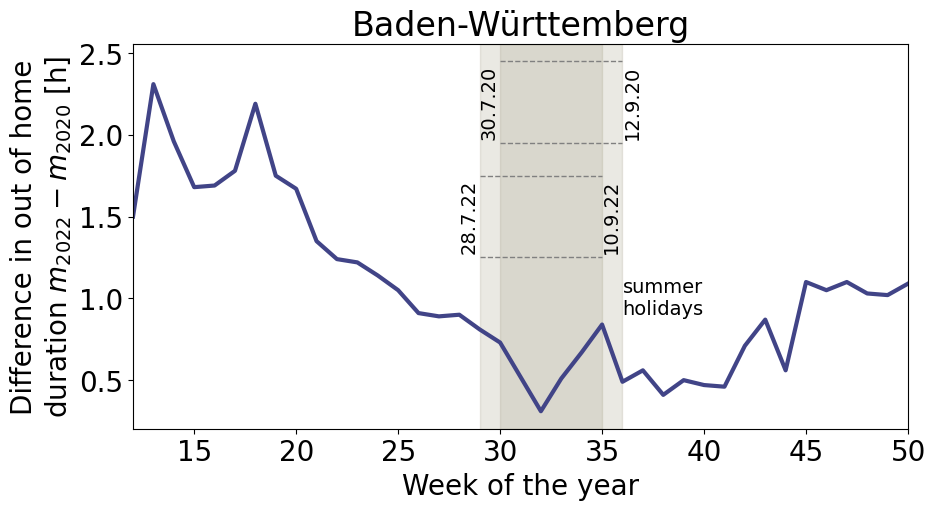

In [92]:
# subtract 2020 mobility from 2022 mobility
differences_m_BW = mobility_BW_2022.values - mobility_BW_2020.values
# color
color_BW = colormap_states(population_bundesland.loc["Baden-Württemberg"]["Einwohner"]/max_pop)
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
xs = mobility_df_2020["week"]
ax.plot(xs, differences_m_BW, linewidth=3, color=color_m_obs)

fs = 14
lw = 1

# set label beside vertical line
ha = "left"
autumn_2020_height = 2.2
autumn_2022_height = 1.5
## summer 2020
ax.text(xs[17], autumn_2020_height, "30.7.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[24], autumn_2020_height, "12.9.20", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
## summer 2022
ax.text(xs[16], autumn_2022_height, "28.7.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)
ax.text(xs[23], autumn_2022_height, "10.9.22", rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)

## name holidays
ax.text(
    xs[26], 1, "summer\nholidays", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs
    )

# plot horizontal dashed line to show length of school holidays
delta = 0.25
## summer 2020
ax.hlines(autumn_2020_height-delta, xs[18], xs[24], linestyle="--", linewidth=lw, color="grey")
ax.hlines(autumn_2020_height+delta, xs[18], xs[24], linestyle="--", linewidth=lw, color="grey")
## summer 2022
ax.hlines(autumn_2022_height-delta, xs[17], xs[23], linestyle="--", linewidth=lw, color="grey")
ax.hlines(autumn_2022_height+delta, xs[17], xs[23], linestyle="--", linewidth=lw, color="grey")

# fill between vertical lines for each holiday
## summer 2020
ax.axvspan(xs[18], xs[24], alpha=0.2, color=color_BW)
## summer 2022
ax.axvspan(xs[17], xs[23], alpha=0.2, color=color_BW)

#ax.legend()
ax.set_title("Baden-Württemberg")
ax.set_xlim(xs[0], xs[-1])
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2022}} - m_{{2020}}$ [h]")

Visualise different holiday states on general mobility difference plot

Text(0, 0.5, 'Difference in out of home\nduration $m_{2022} - m_{2020}$ [h]')

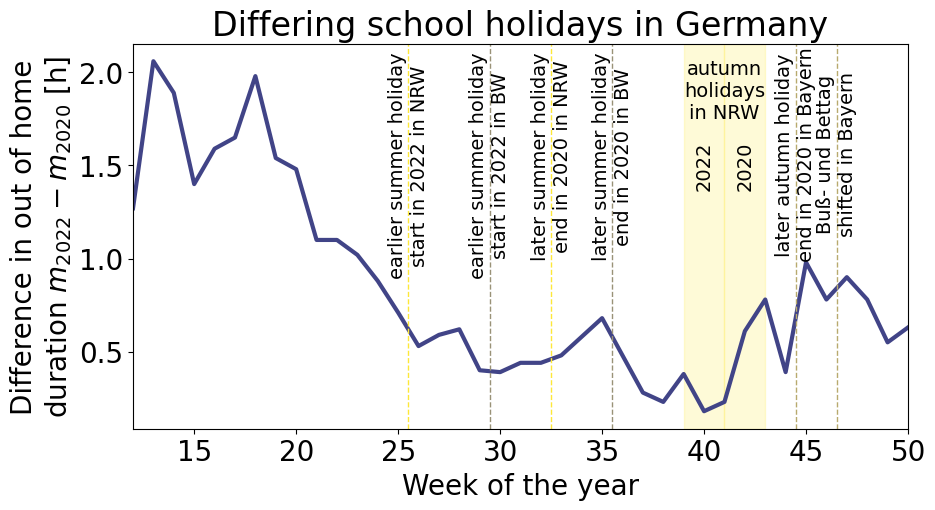

In [123]:
def plot_holiday(x_in, string_in, color_in, ax_in, height_in, ha="center"):
    fs = 14
    lw = 1
    ls = "--"

    # plot vertical dashed line for problematic date/week
    ax_in.axvline(x_in, linestyle=ls, linewidth=lw, color=color_in)
    # set label beside vertical line
    ax_in.text(x_in, height_in, string_in, rotation=90, verticalalignment='center', horizontalalignment=ha, fontsize=fs)


# subtract 2020 mobility from 2022 mobility
differences_m = mobility_data_2022.values - mobility_data_2020.values
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
xs = mobility_df_2020["week"]
ax.plot(xs, differences_m, linewidth=3, color=color_m_obs)

# plot vertical dashed lines for problematic dates/weeks
plot_holiday(25.5, "earlier summer holiday\nstart in 2022 in NRW", color_NRW, ax, 1.5)
plot_holiday(32.5, "later summer holiday\nend in 2020 in NRW", color_NRW, ax, 1.55)
plot_holiday(29.5, "earlier summer holiday\nstart in 2022 in BW", color_BW, ax, 1.5)
plot_holiday(35.5, "later summer holiday\nend in 2020 in BW", color_BW, ax, 1.55)
plot_holiday(44.5, "later autumn holiday\nend in 2020 in Bayern", color_Bayern, ax, 1.56)
plot_holiday(46.5, "Buß- und Bettag\nshifted in Bayern", color_Bayern, ax, 1.56)

### autumn holidays NRW
ax.axvspan(xs[27], xs[29], alpha=0.2, color=color_NRW)
ax.axvspan(xs[29], xs[31], alpha=0.2, color=color_NRW)
ax.text(
    41, 1.9, "autumn\nholidays\nin NRW", rotation=0, verticalalignment='center', horizontalalignment='center', fontsize=fs
    )
ax.text(
    40, 1.5, "2022", rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=fs
    )
ax.text(
    42, 1.5, "2020", rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=fs
    )

ax.set_title("Differing school holidays in Germany")
ax.set_xlim(xs[0], xs[-1])
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2022}} - m_{{2020}}$ [h]")

To do:
* Smoothing reasonable
* ask Ricardo how national values are made from state values
* Smoothing methods to try:
    * average over 3 data points
    * replace weekly value 
        * by weekend value if baseline should be in school holiday
        * by business day value if baseline should not be in school holiday